
# importación de librerias

In [1]:
from pandas import read_csv
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np


# Parte #1

## Importación de datos

In [2]:
S = read_csv('Datos\\Lampara_con_muestra.csv', delimiter= ';', skiprows = 32, skipfooter=2, engine='python')
D = read_csv('Datos\\Lampara_apagada.csv',delimiter = ';', skiprows = 32, skipfooter=2,engine='python')
R = read_csv('Datos\\Lampara_sin_muestra.csv',delimiter = ';', skiprows = 32, skipfooter=2, engine='python')
B = read_csv('Datos\\ThorBB2000.csv',delimiter = ';', skiprows = 69,skipfooter=2, engine='python')

In [3]:

L = S.index.to_numpy() #convertimos a array los datos de las longitudes de onda
S = S['[Data]'].to_numpy()#convertimos a array los datos de las intensidades
R = R['[Data]'].to_numpy()
D = D['[Data]'].to_numpy()
B = B['[Data]'].to_numpy()
I = B * ((S - D)/(R - D))#Calculo del espectro de irradiancia de la lámpara



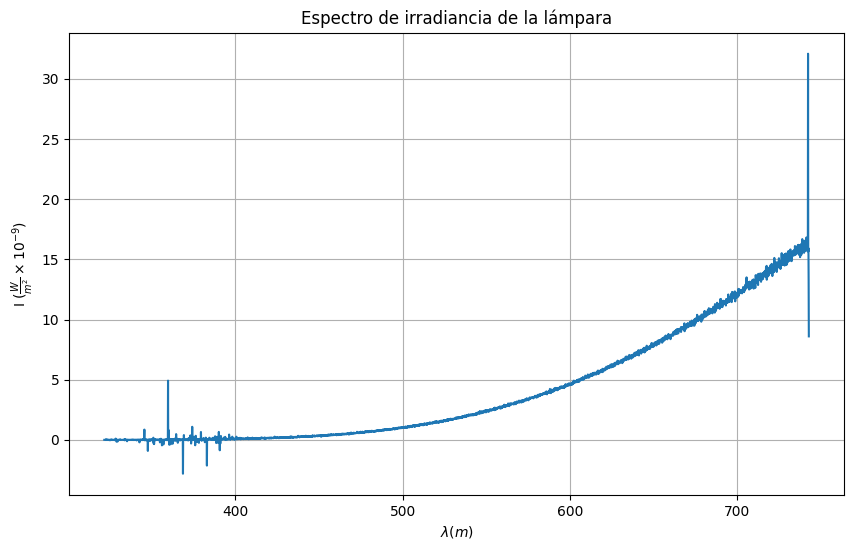

In [4]:
#Gráfica de la intensidad del espectro de irradidancia
plt.figure(figsize=(10,6))
plt.title("Espectro de irradiancia de la lámpara")
plt.plot(L, I*1e9)
plt.ylabel(f"I ($\\frac{{W}}{{m^2}} \\times 10^{{-9}}$) ")
plt.xlabel(f'$\\lambda(m)$')
plt.grid()
plt.show()


In [5]:
#función exponencial que será usada para el ajuste

def fL (l, a,b):
    '''Esta función realiza un ajuste a la potencia
    por unidad de area para el espectro de irradiancia
    
    Parámetros:
    a : parámetro de ajuste
    b : parámetro de ajuste
    l: longitud de onda, variable independiente
    
    Salidas: 
    funcion del espectro de irradiancia en función de la 
    longitud de onda.
    '''

    return a * 1/(l**5 *(np.exp(b/l)-1))

In [6]:
par, cov = curve_fit(fL, L, I)

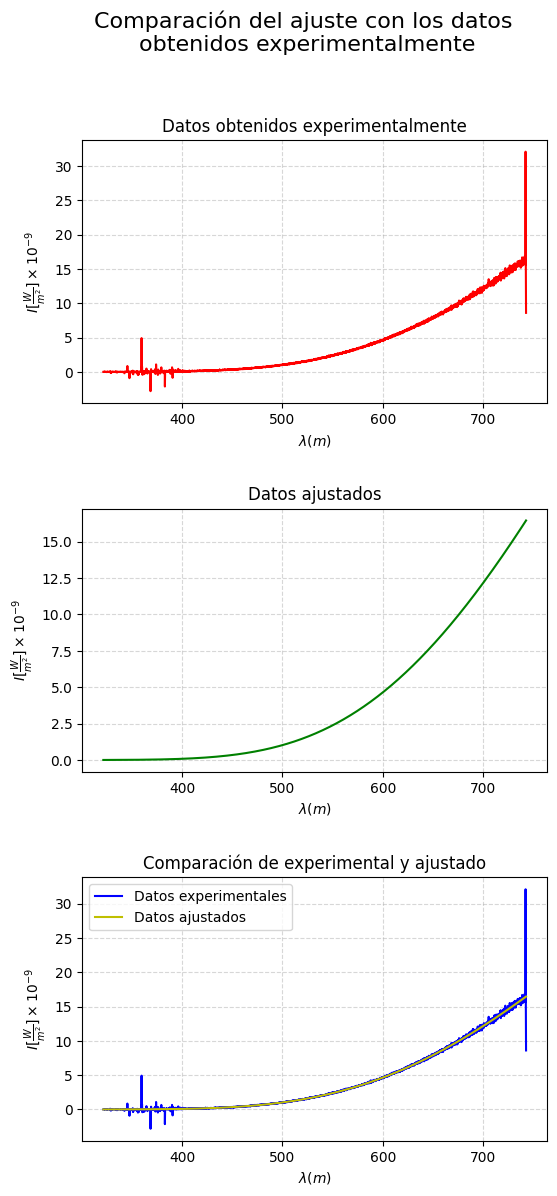

In [7]:
a = par[0]
b = par[1]

fig , axs = plt.subplots(3,1, figsize = (6, 13))
fig.suptitle('Comparación del ajuste con los datos \nobtenidos experimentalmente', size = 16)
fig.subplots_adjust(hspace=0.4)

#--- Gráfica 1 ---
axs[0].plot(L, I*1e9, 'r')
axs[0].set_title('Datos obtenidos experimentalmente')
axs[0].set_xlabel(f'$\\lambda (m)$')
axs[0].set_ylabel(f'$I [\\frac{{W}}{{m^2}}] \\times 10^{{-9}}$')
axs[0].grid(alpha = 0.5, linestyle = '--')

#--- Gráfica 2 ---
axs[1].plot(L, fL(L, a, b)*1e9, 'g')
axs[1].set_title('Datos ajustados')
axs[1].set_xlabel(f'$\\lambda (m)$')
axs[1].set_ylabel(f'$I [\\frac{{W}}{{m^2}}] \\times 10^{{-9}}$')
axs[1].grid(alpha = 0.5, linestyle = '--')

#--- Gráfica 1 ---
axs[2].plot(L, I*1e9, 'b', label = 'Datos experimentales')
axs[2].plot(L, fL(L, a, b)*1e9, 'y',label = 'Datos ajustados')
axs[2].legend()
axs[2].set_title('Comparación de experimental y ajustado')
axs[2].set_xlabel(f'$\\lambda (m)$')
axs[2].set_ylabel(f'$I [\\frac{{W}}{{m^2}}] \\times 10^{{-9}}$')
axs[2].grid(alpha = 0.5, linestyle = '--')


fig.savefig('Articulo\\Imagenes\\Comparación_con_el_ajuste')




## Chi cuadrado

# Parte #2

## Importación del espectro de otras fuentes

In [8]:
M = read_csv('Datos\\Lampara_mercurio_argon.csv', delimiter= ';', skiprows = 32, skipfooter=2, engine='python') #Lámpara de mercurio argón
L = read_csv('Datos\\Lampara_led.csv', delimiter= ';', skiprows = 32, skipfooter=2, engine='python') #Lámpara led
F = read_csv('Datos\\Lampara_fluorescente.csv', delimiter= ';', skiprows = 32, skipfooter=2, engine='python')# Lámpara fluorecente
C = read_csv('Datos\\Pantalla_celular.csv', delimiter= ';', skiprows = 32, skipfooter=2, engine='python') # Pantalla celular
D = read_csv('Datos\\Pantalla_de_celular_lcd.csv', delimiter= ';', skiprows = 32, skipfooter=2, engine='python')# Pantalla celular lcd

In [9]:
# Pasamos los datos que necesitamos a formato numpy
l = M.index
M = M.to_numpy()
L = L.to_numpy()
F = F.to_numpy()
C = C.to_numpy()
D = D.to_numpy()
l = l.to_numpy()


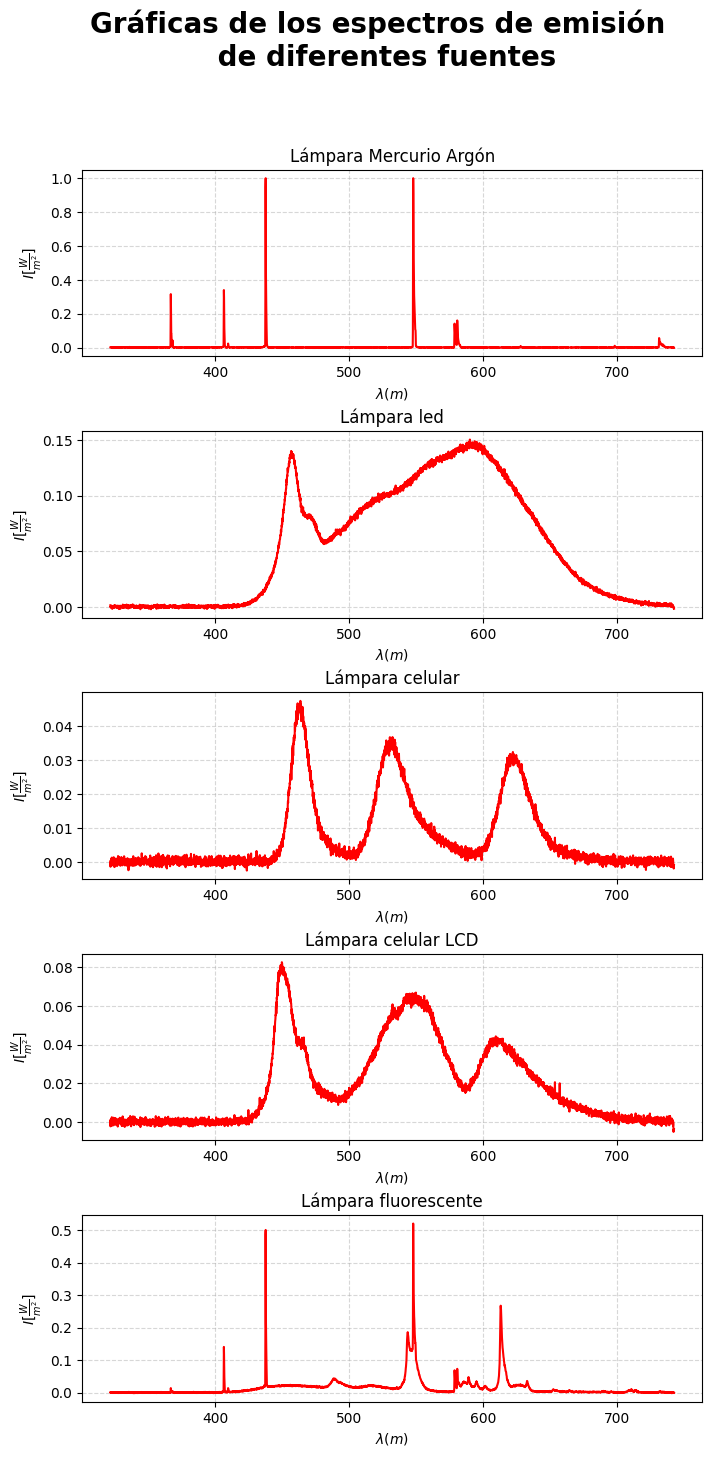

In [10]:
# Gráficamos para observar los espectros de emisión

fig , axs = plt.subplots(5,1, figsize = (8, 16))
fig.suptitle('Gráficas de los espectros de emisión \n de diferentes fuentes', size = 20, fontweight = 'bold')
fig.subplots_adjust(hspace=0.4)

#--- Gráfica 1 ---
axs[0].plot(l, M, 'r')
axs[0].set_title('Lámpara Mercurio Argón')
axs[0].set_xlabel(f'$\\lambda (m)$')
axs[0].set_ylabel(f'$I [\\frac{{W}}{{m^2}}] $')
axs[0].grid(alpha = 0.5, linestyle = '--')

#--- Gráfica 2 ---
axs[1].plot(l, L, 'r')
axs[1].set_title('Lámpara led')
axs[1].set_xlabel(f'$\\lambda (m)$')
axs[1].set_ylabel(f'$I [\\frac{{W}}{{m^2}}]$')
axs[1].grid(alpha = 0.5, linestyle = '--')

#--- Gráfica 3 ---
axs[2].plot(l, C, 'r')
axs[2].set_title('Lámpara celular')
axs[2].set_xlabel(f'$\\lambda (m)$')
axs[2].set_ylabel(f'$I [\\frac{{W}}{{m^2}}] $')
axs[2].grid(alpha = 0.5, linestyle = '--')

#--- Gráfica 4 ---
axs[3].plot(l, D, 'r')
axs[3].set_title('Lámpara celular LCD')
axs[3].set_xlabel(f'$\\lambda (m)$')
axs[3].set_ylabel(f'$I [\\frac{{W}}{{m^2}}]$')
axs[3].grid(alpha = 0.5, linestyle = '--')

#--- Gráfica 5 ---
axs[4].plot(l, F, 'r')
axs[4].set_title('Lámpara fluorescente')
axs[4].set_xlabel(f'$\\lambda (m)$')
axs[4].set_ylabel(f'$I [\\frac{{W}}{{m^2}}] $')
axs[4].grid(alpha = 0.5, linestyle = '--')

fig.savefig('Articulo\\Imagenes\\espectros_de_otras_lámparas.png')
